# Importar Librerías

In [281]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Importación de datos

In [282]:
df = pd.read_excel('data.comida.xlsx')

df.head()

,OrderID,ShipperName,CustomerID,PostalCode,ProductID,UnitPrice,Quantity,Discount,ExtendedPrice,Freight,...,CompanyName,ContactName,ContactTitle,City,Country,Region,ProductName,SupplierID,CategoryID,CategoryName
0,10692,United Package,ALFKI,12209,63,43.9,20,0.0,878,61.0,...,Alfreds Futterkiste,Maria Anders,Sales Representative,Berlin,Germany,Europe,Vegie-spread,7,2,Condiments
1,10702,Speedy Express,ALFKI,12209,3,10.0,6,0.0,60,23.9,...,Alfreds Futterkiste,Maria Anders,Sales Representative,Berlin,Germany,Europe,Aniseed Syrup,1,2,Condiments
2,10702,Speedy Express,ALFKI,12209,76,18.0,15,0.0,270,23.9,...,Alfreds Futterkiste,Maria Anders,Sales Representative,Berlin,Germany,Europe,Lakkalikööri,23,1,Beverages
3,10835,Federal Shipping,ALFKI,12209,59,55.0,15,0.0,825,69.5,...,Alfreds Futterkiste,Maria Anders,Sales Representative,Berlin,Germany,Europe,Raclette Courdavault,28,4,Dairy Products
4,10952,Speedy Express,ALFKI,12209,28,45.6,2,0.0,91,40.4,...,Alfreds Futterkiste,Maria Anders,Sales Representative,Berlin,Germany,Europe,Rössle Sauerkraut,12,7,Produce


In [283]:
df.shape

(3297, 24)

# OBJETIVOS DEL PROYECTO

Se cuenta con una base de datos de un empresa destinada a la venta de productos por el mundo.

Se solicita determinar si existe algun patron o similitud entre los diferentes cliente para poder generar una campaña de marketing.

## pre-analisis

In [284]:
#Control de duplicados
df.duplicated().sum()

np.int64(0)

In [285]:
#Control de nulos
df.isna().sum()

OrderID           0
ShipperName       0
CustomerID        0
PostalCode       93
ProductID         0
UnitPrice         0
Quantity          0
Discount          0
ExtendedPrice     0
Freight           0
Order_Date        0
Required_Date     0
Shipped_Date      0
Cost              0
CompanyName       0
ContactName       0
ContactTitle      0
City              0
Country           0
Region            0
ProductName       0
SupplierID        0
CategoryID        0
CategoryName      0
dtype: int64

La base cuenta con 24 columnas y más de 3000 filas:

Es una tabla combinadas tres fuentes de información:

Tabla ticket: Orden ID, Shpper,ID cliente, cod postal, Producto ID, Precio, Cantidad,etc
Tabla clientes: compañia, nombre, titulo, ciudad, pais, region
Tabla Produt: nombre producto, categoria.

Vamos limpiar la tabla para contar con los datos más caracteristicos del analisis.

In [286]:
df = df.drop(["ExtendedPrice", "CustomerID", "PostalCode", "Discount", 
                        "Freight", "ProductID", "City", "SupplierID", 
                        "CategoryID", "Required_Date","Cost","Shipped_Date","ShipperName"], axis=1)

df.head()

,OrderID,UnitPrice,Quantity,Order_Date,CompanyName,ContactName,ContactTitle,Country,Region,ProductName,CategoryName
0,10692,43.9,20,2021-10-03,Alfreds Futterkiste,Maria Anders,Sales Representative,Germany,Europe,Vegie-spread,Condiments
1,10702,10.0,6,2021-10-13,Alfreds Futterkiste,Maria Anders,Sales Representative,Germany,Europe,Aniseed Syrup,Condiments
2,10702,18.0,15,2021-10-13,Alfreds Futterkiste,Maria Anders,Sales Representative,Germany,Europe,Lakkalikööri,Beverages
3,10835,55.0,15,2022-01-15,Alfreds Futterkiste,Maria Anders,Sales Representative,Germany,Europe,Raclette Courdavault,Dairy Products
4,10952,45.6,2,2022-03-16,Alfreds Futterkiste,Maria Anders,Sales Representative,Germany,Europe,Rössle Sauerkraut,Produce


In [287]:
#Validamos que cantidad de datos diferentes tiene el df
df.nunique()

OrderID         830
UnitPrice       116
Quantity         55
Order_Date      779
CompanyName      89
ContactName      89
ContactTitle     12
Country          21
Region            3
ProductName      77
CategoryName      8
dtype: int64

In [288]:
# al revisar la base de datos se detecta que los OrdenID fueron cargados mal. Distintas fechas para el mismo ID.

#Por lo tanto se eliminará y se creará un nuevo OrdenID único para cada fila.

print(df[df["OrderID"] == 10702])

      OrderID  UnitPrice  Quantity Order_Date          CompanyName  \
1       10702       10.0         6 2021-10-13  Alfreds Futterkiste   
2       10702       18.0        15 2021-10-13  Alfreds Futterkiste   
2561    10702       10.0         6 2022-10-13  Alfreds Futterkiste   
2562    10702       18.0        15 2022-10-13  Alfreds Futterkiste   

       ContactName          ContactTitle  Country  Region    ProductName  \
1     Maria Anders  Sales Representative  Germany  Europe  Aniseed Syrup   
2     Maria Anders  Sales Representative  Germany  Europe   Lakkalikööri   
2561  Maria Anders  Sales Representative  Germany  Europe  Aniseed Syrup   
2562  Maria Anders  Sales Representative  Germany  Europe   Lakkalikööri   

     CategoryName  
1      Condiments  
2       Beverages  
2561   Condiments  
2562    Beverages  


In [289]:
#Reemplazar los ID por un valor único
df["OrderID"] = range(1, len(df) + 1)

df.tail()

,OrderID,UnitPrice,Quantity,Order_Date,CompanyName,ContactName,ContactTitle,Country,Region,ProductName,CategoryName
3292,3293,49.30,10,2022-06-19,Trail's Head Gourmet Provisioners,Helvetius Nagy,Sales Associate,USA,North America,Tarte au sucre,Confections
3293,3294,33.25,6,2022-06-19,Trail's Head Gourmet Provisioners,Helvetius Nagy,Sales Associate,USA,North America,Wimmers gute Semmelknödel,Grains/Cereals
3294,3295,18.00,10,2022-06-23,Trail's Head Gourmet Provisioners,Helvetius Nagy,Sales Associate,USA,North America,Chartreuse verte,Beverages
3295,3296,7.75,20,2022-06-23,Trail's Head Gourmet Provisioners,Helvetius Nagy,Sales Associate,USA,North America,Rhönbräu Klosterbier,Beverages
3296,3297,13.00,18,2022-06-23,Trail's Head Gourmet Provisioners,Helvetius Nagy,Sales Associate,USA,North America,Original Frankfurter grüne Soße,Condiments


In [290]:
#Agregar la columna Ventas como PxQ
df["Ventas"] = df["UnitPrice"] * df["Quantity"]

In [291]:
#simplificar nombres

df= df.rename(columns={
    "OrderID":"Ticket",
    "UnitPrice":"P",
    "Quantity":"Q",
    "Order_Date":"Fecha",
    "CompanyName":"Empresa",
    "ContactName":"Cliente",
    "ProductName":"Producto",
    "CategoryName":"CategoriaProd"})

df= df[["Ticket","Fecha","CategoriaProd","Producto","P","Q","Ventas","Region","Country","Empresa","Cliente","ContactTitle"]]

df

,Ticket,Fecha,CategoriaProd,Producto,P,Q,Ventas,Region,Country,Empresa,Cliente,ContactTitle
0,1,2021-10-03,Condiments,Vegie-spread,43.90,20,878.0,Europe,Germany,Alfreds Futterkiste,Maria Anders,Sales Representative
1,2,2021-10-13,Condiments,Aniseed Syrup,10.00,6,60.0,Europe,Germany,Alfreds Futterkiste,Maria Anders,Sales Representative
2,3,2021-10-13,Beverages,Lakkalikööri,18.00,15,270.0,Europe,Germany,Alfreds Futterkiste,Maria Anders,Sales Representative
3,4,2022-01-15,Dairy Products,Raclette Courdavault,55.00,15,825.0,Europe,Germany,Alfreds Futterkiste,Maria Anders,Sales Representative
4,5,2022-03-16,Produce,Rössle Sauerkraut,45.60,2,91.2,Europe,Germany,Alfreds Futterkiste,Maria Anders,Sales Representative
...,...,...,...,...,...,...,...,...,...,...,...,...
3292,3293,2022-06-19,Confections,Tarte au sucre,49.30,10,493.0,North America,USA,Trail's Head Gourmet Provisioners,Helvetius Nagy,Sales Associate
3293,3294,2022-06-19,Grains/Cereals,Wimmers gute Semmelknödel,33.25,6,199.5,North America,USA,Trail's Head Gourmet Provisioners,Helvetius Nagy,Sales Associate
3294,3295,2022-06-23,Beverages,Chartreuse verte,18.00,10,180.0,North America,USA,Trail's Head Gourmet Provisioners,Helvetius Nagy,Sales Associate
3295,3296,2022-06-23,Beverages,Rhönbräu Klosterbier,7.75,20,155.0,North America,USA,Trail's Head Gourmet Provisioners,Helvetius Nagy,Sales Associate


# Descripción de datos númericos y Valores más usuales

In [292]:
df.describe()

,Ticket,Fecha,P,Q,Ventas
count,3297.000000,3297,3297.000000,3297.000000,3297.000000
mean,1649.000000,2021-09-02 13:31:30.081892608,26.086430,23.710039,617.399621
min,1.000000,2020-01-02 00:00:00,2.000000,1.000000,4.800000
25%,825.000000,2021-01-06 00:00:00,12.000000,10.000000,155.000000
50%,1649.000000,2021-10-27 00:00:00,18.400000,20.000000,360.000000
75%,2473.000000,2022-04-27 00:00:00,32.000000,30.000000,728.000000
max,3297.000000,2022-12-31 00:00:00,263.500000,130.000000,15810.000000
std,951.906245,NaN,29.208349,18.850417,962.484453


Checks a tener encuenta:

Precio positivo: ok
Cantidad positiva: ok
datos anómalos: ajustar - la media de P fue 26 pero el Pmax 263

In [293]:
#Valores más repetidos de las cantidades
for col in ["Q", "Country", "Cliente"]:
    print(f"Frecuencia de valores en {col}:")
    print(df[col].value_counts().head(7))

Frecuencia de valores en Q:
Q
20    384
30    294
10    279
15    270
40    176
12    140
6     137
Name: count, dtype: int64
Frecuencia de valores en Country:
Country
USA          550
Germany      522
Brazil       312
France       275
UK           210
Austria      193
Venezuela    169
Name: count, dtype: int64
Frecuencia de valores en Cliente:
Cliente
Jose Pavarotti        184
Roland Mendel         154
Horst Kloss           133
Paula Wilson           98
Patricia McKenna       93
Peter Franken          85
Christina Berglund     82
Name: count, dtype: int64


# INICIAR EL PROYECTO

Para determinar el patrón entre los distintos de clientes. Analizaremos:
Tiempo transcurrido desde la ultima compra,
la ventas realizadas por cliente y
cantidad de veces realizo pedidos.

In [294]:
# Determinar la ultima fecha de la base de datos
end_date = max(df["Fecha"]) + pd.Timedelta(days=1)
max(df["Fecha"])

print (end_date)

2023-01-01 00:00:00


In [295]:
#Crear las variables de análisis y el Df que almacene la info de los clientes.

df1= df.groupby ("Cliente").agg(

Ultima_compra = ("Fecha", lambda x: (end_date - x.max()).days),

Transacciones = ("Ticket", "count"),

Ingresos = ("Ventas" , "sum")
)

df1.head(5)

,Ultima_compra,Transacciones,Ingresos
Cliente,,,
Alejandra Camino,267,22,2207.69
Alexander Feuer,16,20,9839.40
Ana Trujillo,34,16,2291.50
Anabela Domingues,163,17,10019.62
André Fonseca,10,33,15887.46


In [296]:
df1.Ingresos.mean().round(2)

np.float64(22871.53)

In [297]:
df1.shape

(89, 3)

# PRIMERAS CONCLUSIONES

Ultima_compra: 


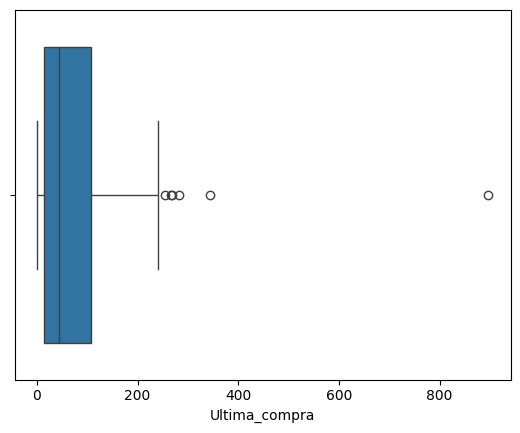

Transacciones: 


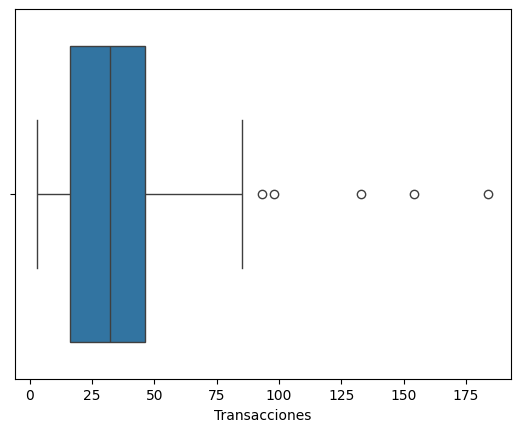

Ingresos: 


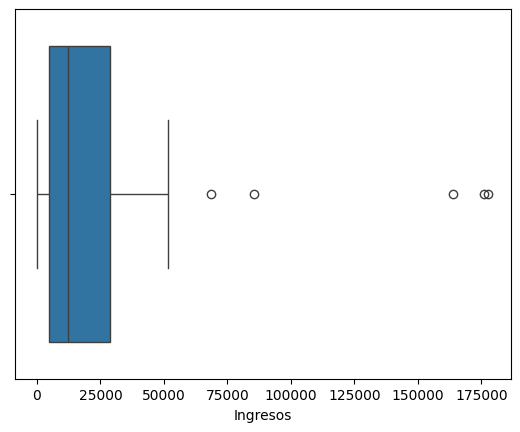

In [298]:
for i in df1.columns:
    print (str(i)+': ')
    ax = sns.boxplot (x =df1[str(i)])
    plt.show()

La base tiene datos anomalos para limpiar.

In [299]:
Q1 = df1.quantile(0.25)
Q3 = df1.quantile(0.75)

# Calcular el rango intercuartílico (IQR)
IQR = Q3 - Q1

# Filtrar los valores que están dentro del rango de IQR
df1_ajustado= df1[~((df1 < (Q1 - 1.5 * IQR)) | (df1 > (Q3 + 1.5 * IQR))).any(axis=1)]

# Mostrar el DataFrame limpio
print(df1_ajustado)

                         Ultima_compra  Transacciones  Ingresos
Cliente                                                        
Alexander Feuer                     16             20   9839.40
Ana Trujillo                        34             16   2291.50
Anabela Domingues                  163             17  10019.62
André Fonseca                       10             33  15887.46
Ann Devon                           59             27  17435.01
...                                ...            ...       ...
Yang Wang                           43             34  18987.20
Yoshi Latimer                      115             16   6024.00
Yoshi Tannamuri                    149             10    580.00
Yvonne Moncada                     238             12   3570.20
Zbyszek Piestrzeniewicz              9             24   5198.80

[78 rows x 3 columns]


# Conclusiones 2

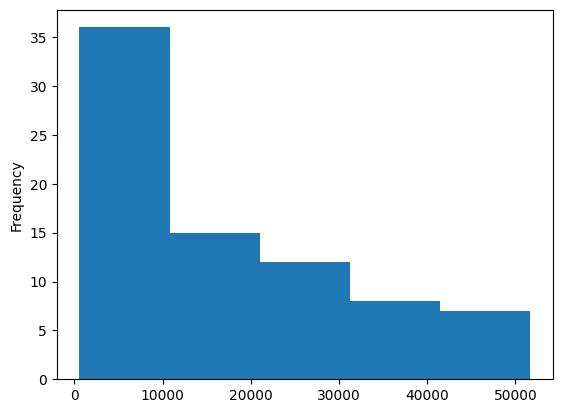

In [300]:
df1_ajustado.Ingresos.plot.hist(bins=5)
plt.show()

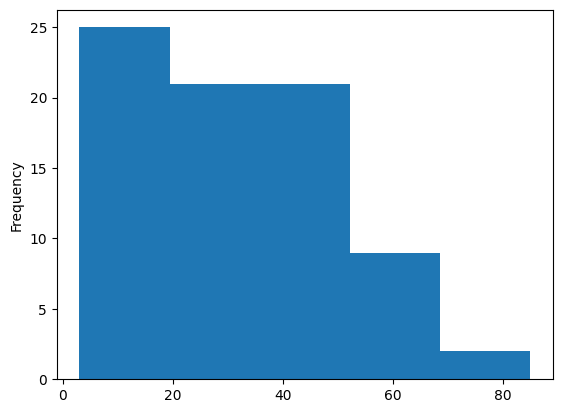

In [301]:
df1_ajustado.Transacciones.plot.hist(bins=5)
plt.show()

# Conclusiones 3

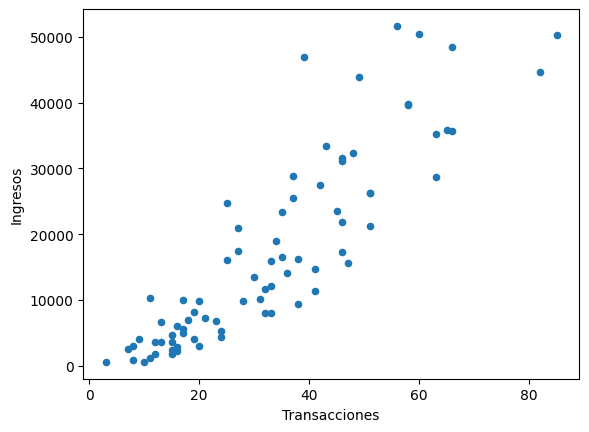

In [302]:
df1_ajustado.plot("Transacciones","Ingresos", kind="scatter")
plt.show()

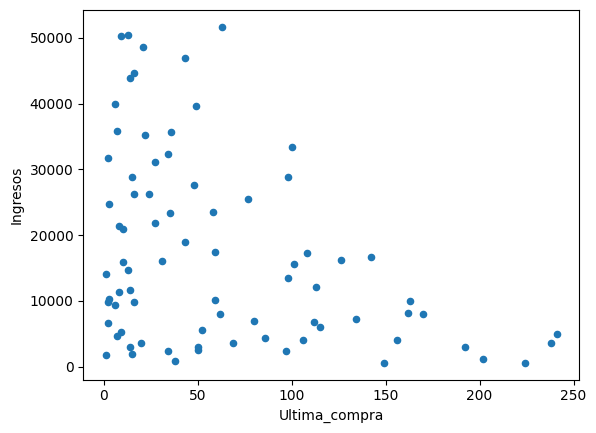

In [303]:
df1_ajustado.plot("Ultima_compra","Ingresos", kind="scatter")
plt.show()

# Procesar datos para Kmeans

In [304]:
df_log = np.log1p(df1_ajustado)

In [305]:
pip install scikit-learn

In [306]:
from sklearn.preprocessing import StandardScaler 

scaler = StandardScaler()
scaler.fit(df_log)

df_norm= scaler.transform(df_log)

In [307]:
df_norm= pd.DataFrame(df_norm, columns=["Ultima_compra","Transacciones","Ingresos"], index =df1_ajustado.index)
df_norm.head()

,Ultima_compra,Transacciones,Ingresos
Cliente,,,
Alexander Feuer,-0.567131,-0.495307,-0.082826
Ana Trujillo,0.011003,-0.835737,-1.400993
Anabela Domingues,1.247527,-0.743652,-0.066405
André Fonseca,-0.915642,0.280959,0.350662
Ann Devon,0.442517,-0.031836,0.434759


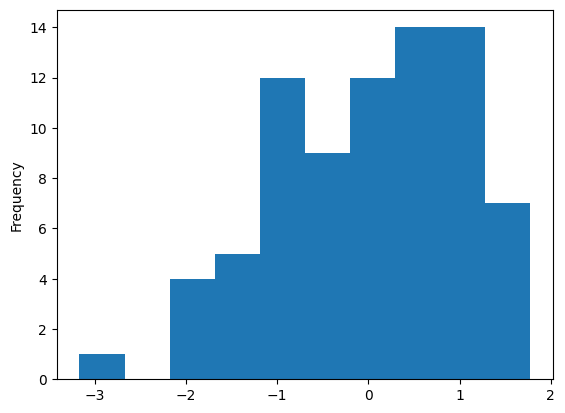

In [308]:
df_norm.Transacciones.plot(kind= "hist")
plt.show()

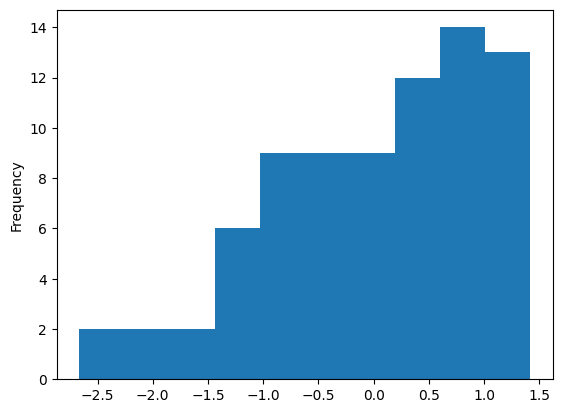

In [309]:
df_norm.Ingresos.plot(kind= "hist")
plt.show()

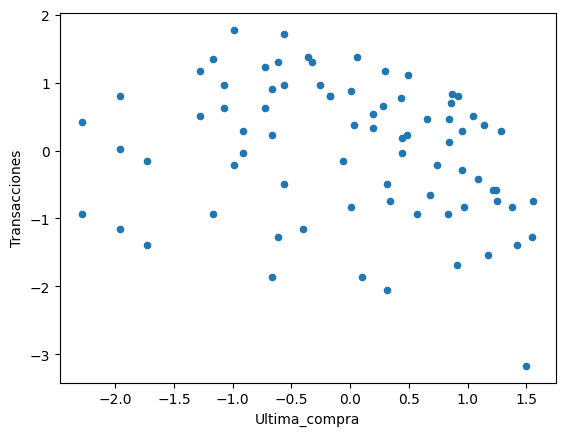

In [310]:
df_norm.plot.scatter("Ultima_compra","Transacciones")
plt.show()

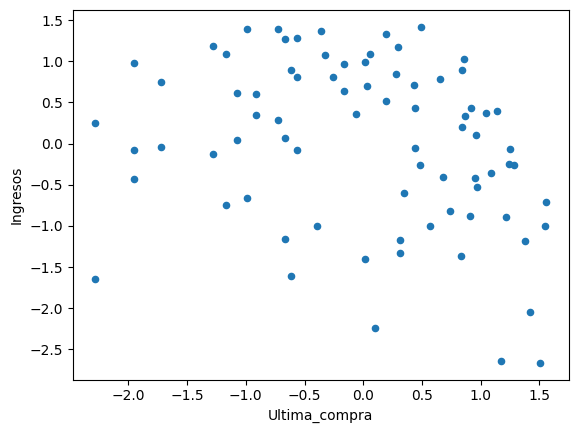

In [311]:
df_norm.plot.scatter("Ultima_compra","Ingresos")
plt.show()

# Clustering

In [312]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=1, n_init="auto")

In [313]:
kmeans.fit(df1_ajustado)

KMeans(n_clusters=4, random_state=1)

In [314]:
np.unique(kmeans.labels_,return_counts=True)

(array([0, 1, 2, 3], dtype=int32), array([36, 14, 19,  9]))

# Crear identificador de cluster

In [315]:
df_norm["cluster"] = kmeans.labels_

In [316]:
df_norm["cluster"]=df_norm["cluster"].astype("category")

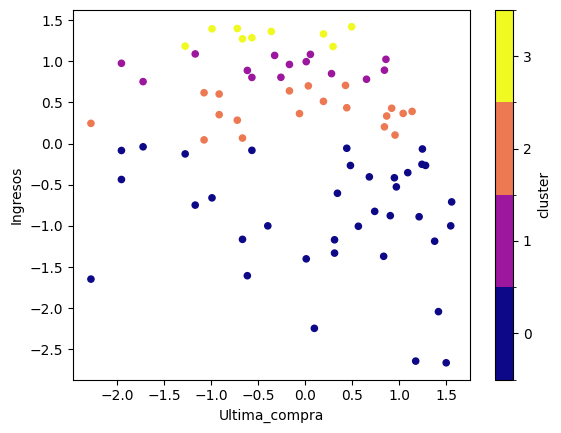

In [317]:
df_norm.plot(x="Ultima_compra", y="Ingresos", c="cluster", kind="scatter",colormap="plasma")
plt.show()

In [318]:
df1_ajustado["cluster"] = kmeans.labels_

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15560\1425882900.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1_ajustado["cluster"] = kmeans.labels_


In [319]:
df1_ajustado["cluster"]=df_norm["cluster"].astype("category")

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15560\1326397569.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1_ajustado["cluster"]=df_norm["cluster"].astype("category")


In [327]:
# Crear tabla resumen con datos promedios


df1_ajustado.groupby("cluster").agg(
    Ultima_compra=("Ultima_compra","mean"),
    Ingresos=("Ingresos","mean"),
    cluster_size=("Ingresos","count"),
    Transacciones=("Transacciones","mean")
    
).round(1).sort_values(by="Ultima_compra")

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15560\2488474253.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df1_ajustado.groupby("cluster").agg(


,Ultima_compra,Ingresos,cluster_size,Transacciones
cluster,,,,
3,26.0,46233.8,9,61.4
1,36.4,30234.7,14,48.8
2,52.9,16975.1,19,36.9
0,87.1,5100.7,36,17.4


# CONCLUSIONES:

La base de datos determino 4 grupos:

Siendo el grupo 3 (estrella) que mayor ingresos genera formado por 9 clientes que generan ingresos superiores a $39k. Se debe buscar la fidelización de los mismos mediante atención personalizada.

Grupo 2: genera ingresos entre $10k-23k pero la frecuencia de compra es baja. Asignar promociones por volumen de compra.

Grupo 1 genera ingresos entre 24k-35k pero la frecuencia de compra es media. Asignar promociones y/o publicidad.

Grupo 0: Clientes con poca compras efectuadas o que realizan compras pequeñas. Automatizar servicio para no emplear recursos adicionales.




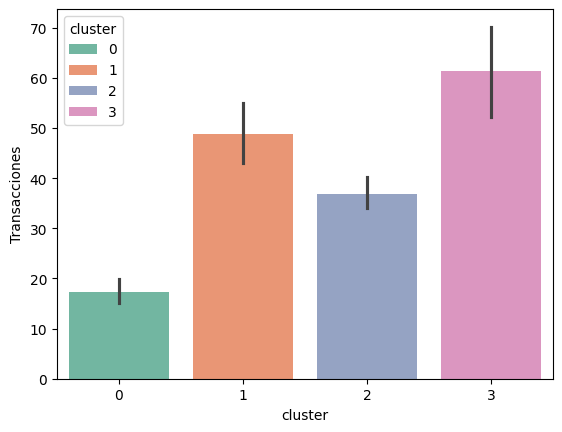

In [329]:
sns.barplot(data=df1_ajustado, x="cluster", y="Transacciones", hue="cluster", palette='Set2')
plt.show()

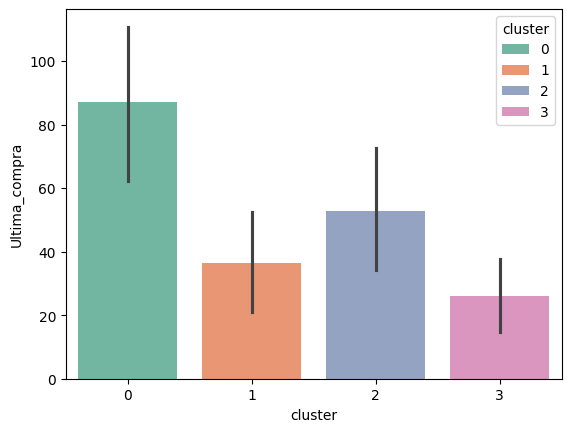

In [330]:
sns.barplot(data=df1_ajustado,x="cluster", y="Ultima_compra",hue="cluster", palette='Set2')
plt.show()

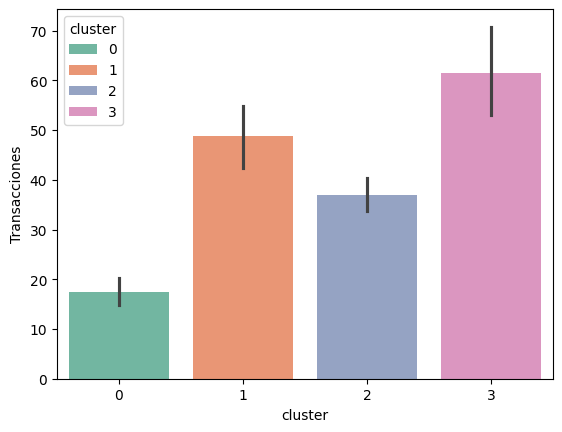

In [331]:
sns.barplot(data=df1_ajustado,x="cluster", y="Transacciones",hue="cluster", palette='Set2')
plt.show()

# Entrega de resultados a la empresa para generar su plan de marketing

In [332]:
# Filtrar los clusters y ordenarlos por "Ingresos"
clusters = {i: df1_ajustado[df1_ajustado["cluster"] == i].sort_values("Ingresos", ascending=False) for i in range(0, 4)}

# Mostrar el DataFrame del cluster 1, por ejemplo
for cluster_id in range(0, 4):
    print(f"\nClientes en Cluster {cluster_id} ordenados por Ingresos:")
    print(clusters[cluster_id])
    print("-" * 40)


Clientes en Cluster 0 ordenados por Ingresos:
                         Ultima_compra  Transacciones  Ingresos cluster
Cliente                                                                
Martín Sommer                        3             11  10315.60       0
Maurizio Moroni                     59             31  10118.60       0
Anabela Domingues                  163             17  10019.62       0
Alexander Feuer                     16             20   9839.40       0
Paula Parente                        2             28   9818.80       0
Helen Bennett                        6             38   9377.60       0
Karin Josephs                      162             19   8156.50       0
Victoria Ashworth                  170             33   8034.60       0
Aria Cruz                           62             32   8028.40       0
Jonas Bergulfsen                   134             21   7293.55       0
Maria Anders                        80             18   6890.20       0
Fran Wilson      